MTF10: 1.43 lp/mm
MTF50: 0.2641 cycles/pixel
MTF10: 0.3866 cycles/pixel


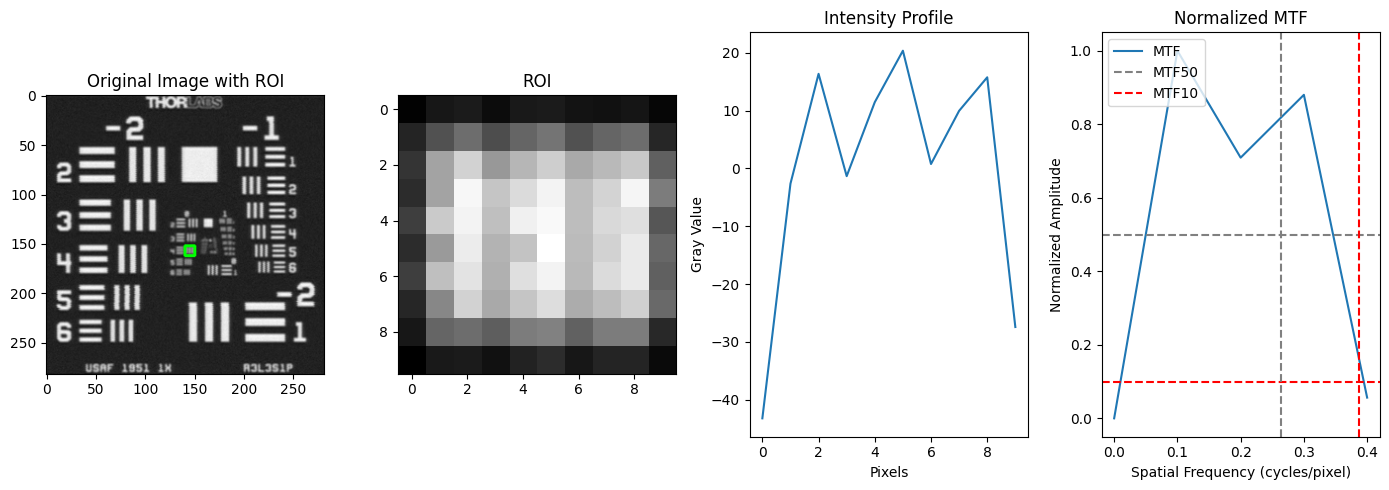

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. 이미지 불러오기 (흑백)
# path = '../results_main/o2o_latest/2.0/resol1951_2_e_2.0THz(1.5to2.0).png'
path = '../hyperspectral/thz_new/resol1951_2_e_2.0THz.png'
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 2. ROI(관심 영역) 설정: (x, y, width, height)
# -> 해상도를 측정하고 싶은 group/element 패턴이 있는 위치로 조정 필요
x, y, w, h = 140, 152, 10, 10
roi = img[y:y+h, x:x+w]

# ROI 영역을 원본 이미지에 표시
img_with_roi = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)  # 컬러 이미지로 변환
cv2.rectangle(img_with_roi, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 녹색 박스 그리기

# 3. intensity profile 계산 (열 평균)
profile = np.mean(roi, axis=0)
profile -= np.mean(profile)  # DC 제거

# 4. FFT 수행
fft_result = np.fft.fft(profile)
fft_magnitude = np.abs(fft_result)[:len(profile)//2]
frequencies = np.fft.fftfreq(len(profile))[:len(profile)//2]

# 5. Normalized MTF 계산 (0~1 스케일)
mtf = fft_magnitude / np.max(fft_magnitude)

# 6. MTF50, MTF10 위치 찾기 (보간 사용)
interp_func = interp1d(mtf, frequencies, bounds_error=False, fill_value="extrapolate")

try:
    mtf50 = float(interp_func(0.5))
    mtf10 = float(interp_func(0.1))
    pixel_pitch_mm = 0.2702
  # 예시: 3.45 µm
    mtf10_lpmm = mtf10 / pixel_pitch_mm
    print(f"MTF10: {mtf10_lpmm:.2f} lp/mm")
    print(f"MTF50: {mtf50:.4f} cycles/pixel")
    print(f"MTF10: {mtf10:.4f} cycles/pixel")
except:
    print("MTF50 또는 MTF10 추정 불가 (profile insufficient)")

# 7. 시각화
plt.figure(figsize=(14, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image with ROI")
plt.imshow(cv2.cvtColor(img_with_roi, cv2.COLOR_BGR2RGB))  # BGR을 RGB로 변환하여 표시
plt.subplot(1, 4, 2)
plt.title("ROI")
plt.imshow(roi, cmap='gray')

plt.subplot(1, 4, 3)
plt.title("Intensity Profile")
plt.plot(profile)
plt.xlabel("Pixels")
plt.ylabel("Gray Value")

plt.subplot(1, 4, 4)
plt.title("Normalized MTF")
plt.plot(frequencies, mtf, label='MTF')
plt.axhline(0.5, color='gray', linestyle='--', label='MTF50')
plt.axhline(0.1, color='red', linestyle='--', label='MTF10')
plt.axvline(mtf50, color='gray', linestyle='--')
plt.axvline(mtf10, color='red', linestyle='--')
plt.xlabel("Spatial Frequency (cycles/pixel)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


최고 해상도 구분 가능 위치: Group 6, Element 6
→ Contrast: 0.744


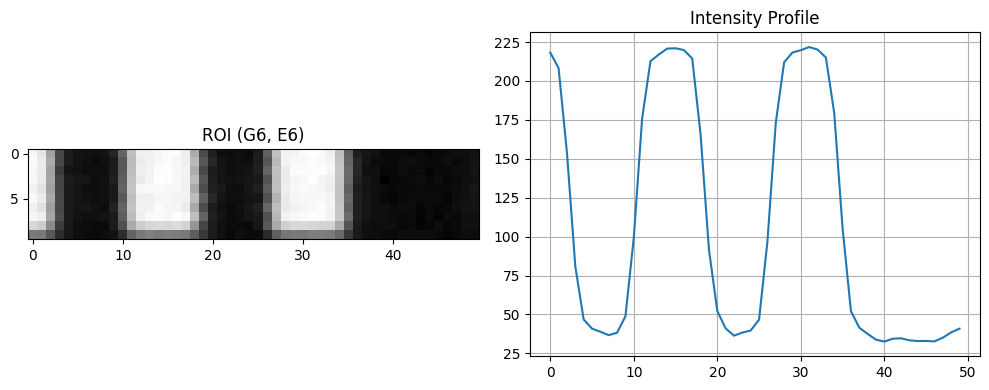

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 이미지 불러오기
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 분석할 그룹/엘리먼트 리스트 (Group -2 to 6, Element 1 to 6)
group_range = range(-2, 7)
element_range = range(1, 7)

# Group/Element 위치 매핑 (이건 사용자 이미지에 맞게 조정 필요)
# 가로로 나열된 형태를 기준으로 임의 설정
# 실제 이미지에 따라 정확한 ROI 위치는 직접 조정해야 함
start_x, start_y = 0, 0  # 시작 좌표
dx, dy = 30, 30  # 각 ROI 간 거리

results = []

for gi, group in enumerate(group_range):
    for ei, element in enumerate(element_range):
        x = start_x + ei * dx
        y = start_y + gi * dy
        w, h = 50, 10  # ROI 크기 (너비, 높이)
        roi = img[y:y+h, x:x+w]

        if roi.shape[0] == 0 or roi.shape[1] == 0:
            continue  # 이미지 바깥 벗어난 경우

        profile = np.mean(roi, axis=0)
        I_max = np.max(profile)
        I_min = np.min(profile)
        contrast = (I_max - I_min) / (I_max + I_min + 1e-8)  # 0으로 나눔 방지

        results.append({
            'group': group,
            'element': element,
            'contrast': contrast,
            'x': x,
            'y': y
        })

# 결과 정렬 (높은 group/element 순으로)
results.sort(key=lambda x: (x['group'], x['element']), reverse=True)

# 구분 가능한 최고 해상도 찾기
threshold = 0.1
for res in results:
    if res['contrast'] >= threshold:
        print(f"최고 해상도 구분 가능 위치: Group {res['group']}, Element {res['element']}")
        print(f"→ Contrast: {res['contrast']:.3f}")
        break
else:
    print("구분 가능한 해상도 없음 (모두 0.1 미만)")

# 선택된 ROI 시각화
plt.figure(figsize=(10, 4))
roi = img[res['y']:res['y']+h, res['x']:res['x']+w]
profile = np.mean(roi, axis=0)

plt.subplot(1, 2, 1)
plt.title(f"ROI (G{res['group']}, E{res['element']})")
plt.imshow(roi, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Intensity Profile")
plt.plot(profile)
plt.grid(True)
plt.tight_layout()
plt.show()


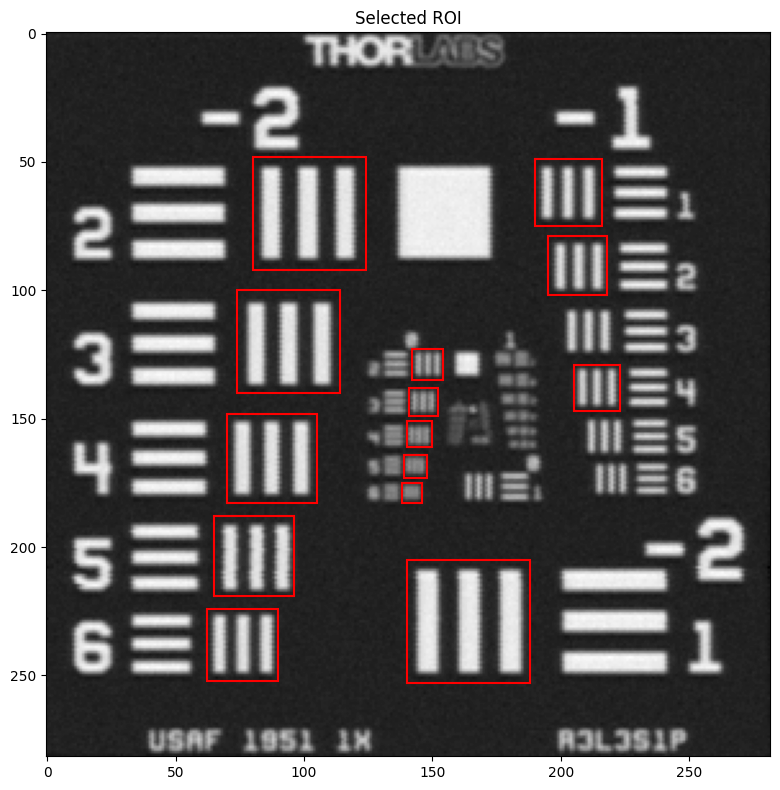

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.interpolate import interp1d

# 이미지 불러오기
image_path = path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# lp/mm 계산 함수
def calc_lpmm(group, element):
    return 2 ** (group + (element - 1) / 6)

# 수동 ROI 정의 (대략적인 위치 기준)
roi_list = [
    {"group": -2, "element": 1, "x": 140, "y": 205, "w": 48, "h": 48},
    {"group": -2, "element": 2, "x": 80, "y": 48, "w": 44, "h": 44},
    {"group": -2, "element": 3, "x": 74, "y": 100, "w": 40, "h": 40},
    {"group": -2, "element": 4, "x": 70, "y": 148, "w": 35, "h": 35},
    {"group": -2, "element": 5, "x": 65, "y": 188, "w": 31, "h": 31},
    {"group": -2, "element": 6, "x": 62, "y": 224, "w": 28, "h": 28},
    {"group": -1, "element": 1, "x": 190, "y": 49, "w": 26, "h": 26},
    {"group": -1, "element": 2, "x": 195, "y": 79, "w": 23, "h": 23},
    {"group": -1, "element": 4, "x": 205, "y": 129, "w": 18, "h": 18},
    {"group":  0, "element": 2, "x": 142, "y": 123, "w": 12, "h": 12},
    {"group":  0, "element": 3, "x": 141, "y": 138, "w": 11, "h": 11},
    {"group":  0, "element": 4, "x": 140, "y": 151, "w": 10, "h": 10},
    {"group":  0, "element": 5, "x": 139, "y": 164, "w": 9, "h": 9},
    {"group":  0, "element": 6, "x": 138, "y": 175, "w": 8, "h": 8},
    # {"group":  1, "element": 1, "x": 174, "y": 123, "w": 7, "h": 7},
]
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.title("Selected ROI")
for roi in roi_list:
    rect = plt.Rectangle((roi["x"], roi["y"]), roi["w"], roi["h"],
                         edgecolor='red', facecolor='none', linewidth=1.5)
    plt.gca().add_patch(rect)
plt.tight_layout()
plt.show()


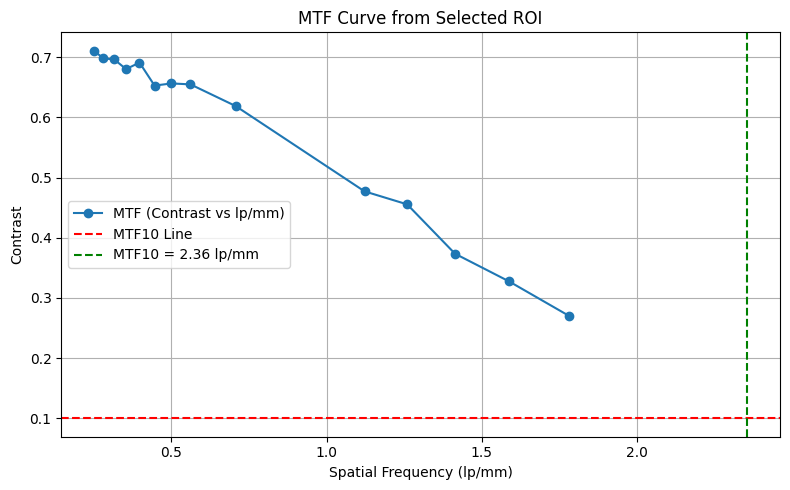

2.3565908386684695

In [8]:
lpmm_vals = []
contrast_vals = []
# Contrast 계산
for roi in roi_list:
    x, y, w, h = roi["x"], roi["y"], roi["w"], roi["h"]
    region = img[y:y+h, x:x+w]
    profile = np.mean(region, axis=0)
    I_max = np.max(profile)
    I_min = np.min(profile)
    contrast = (I_max - I_min) / (I_max + I_min + 1e-8)
    lpmm = calc_lpmm(roi["group"], roi["element"])

    contrast_vals.append(contrast)
    lpmm_vals.append(lpmm)

# MTF 곡선 그리기
sorted_indices = np.argsort(lpmm_vals)
lpmm_vals_sorted = np.array(lpmm_vals)[sorted_indices]
contrast_vals_sorted = np.array(contrast_vals)[sorted_indices]

# 보간을 통한 MTF10 추정
interp_func = interp1d(contrast_vals_sorted, lpmm_vals_sorted, bounds_error=False, fill_value="extrapolate")
try:
    mtf10_lpmm = float(interp_func(0.1))
except:
    mtf10_lpmm = None

# MTF 곡선 시각화
plt.figure(figsize=(8, 5))
plt.plot(lpmm_vals_sorted, contrast_vals_sorted, 'o-', label='MTF (Contrast vs lp/mm)')
plt.axhline(0.1, color='r', linestyle='--', label='MTF10 Line')
if mtf10_lpmm:
    plt.axvline(mtf10_lpmm, color='g', linestyle='--', label=f'MTF10 = {mtf10_lpmm:.2f} lp/mm')
plt.xlabel("Spatial Frequency (lp/mm)")
plt.ylabel("Contrast")
plt.title("MTF Curve from Selected ROI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mtf10_lpmm

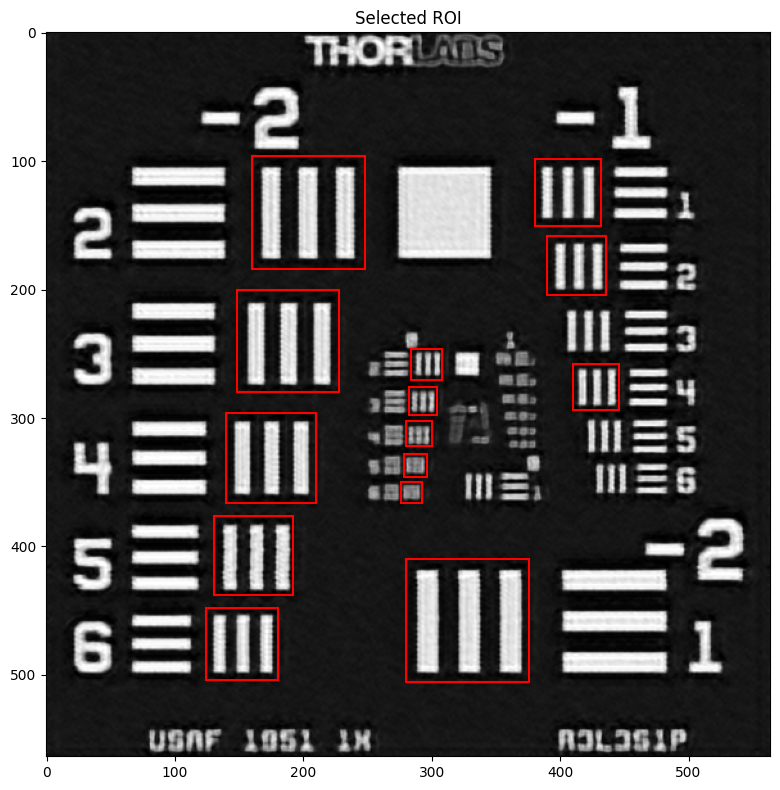

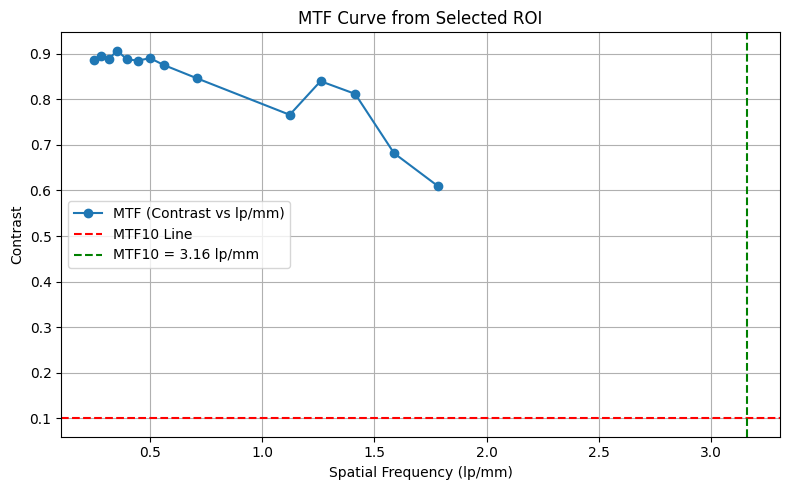

3.162004923989712

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.interpolate import interp1d

# 이미지 불러오기
# image_path = '../results_main/d2d/2.0040/2.0040THz(2.0040to2.5050).png' # 3.1681
# image_path = '../results_main/o2o_latest_ZSSR/2.0/resol1951_2_e_2.0THz(1.5to2.0).png' # 2.8850
image_path = '../results_main/resol1951_2_e_2.0THz(1.5to2.0)_zssr.png' # 3.1620
# image_path = '../results_main/recurrent/resol1951_2_e_2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0)).png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# lp/mm 계산 함수
def calc_lpmm(group, element):
    return 2 ** (group + (element - 1) / 6)

# 수동 ROI 정의 (대략적인 위치 기준)
roi_list = [
    {"group": -2, "element": 1, "x": 140, "y": 205, "w": 48, "h": 48},
    {"group": -2, "element": 2, "x": 80, "y": 48, "w": 44, "h": 44},
    {"group": -2, "element": 3, "x": 74, "y": 100, "w": 40, "h": 40},
    {"group": -2, "element": 4, "x": 70, "y": 148, "w": 35, "h": 35},
    {"group": -2, "element": 5, "x": 65, "y": 188, "w": 31, "h": 31},
    {"group": -2, "element": 6, "x": 62, "y": 224, "w": 28, "h": 28},
    {"group": -1, "element": 1, "x": 190, "y": 49, "w": 26, "h": 26},
    {"group": -1, "element": 2, "x": 195, "y": 79, "w": 23, "h": 23},
    {"group": -1, "element": 4, "x": 205, "y": 129, "w": 18, "h": 18},
    {"group":  0, "element": 2, "x": 142, "y": 123, "w": 12, "h": 12},
    {"group":  0, "element": 3, "x": 141, "y": 138, "w": 11, "h": 11},
    {"group":  0, "element": 4, "x": 140, "y": 151, "w": 10, "h": 10},
    {"group":  0, "element": 5, "x": 139, "y": 164, "w": 9, "h": 9},
    {"group":  0, "element": 6, "x": 138, "y": 175, "w": 8, "h": 8},
    # {"group":  1, "element": 1, "x": 174, "y": 123, "w": 7, "h": 7},
]
if 'zssr' in image_path:
    multiplier = 2
else:
    multiplier = 1

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.title("Selected ROI")
for roi in roi_list:
    rect = plt.Rectangle((roi["x"]*multiplier, roi["y"]*multiplier), roi["w"]*multiplier, roi["h"]*multiplier,
                         edgecolor='red', facecolor='none', linewidth=1.5)
    plt.gca().add_patch(rect)
plt.tight_layout()
plt.show()

lpmm_vals = []
contrast_vals = []
# Contrast 계산
for roi in roi_list:
    x, y, w, h = roi["x"]*multiplier, roi["y"]*multiplier, roi["w"]*multiplier, roi["h"]*multiplier
    region = img[y:y+h, x:x+w]
    profile = np.mean(region, axis=0)
    I_max = np.max(profile)
    I_min = np.min(profile)
    contrast = (I_max - I_min) / (I_max + I_min + 1e-8)
    lpmm = calc_lpmm(roi["group"], roi["element"])

    contrast_vals.append(contrast)
    lpmm_vals.append(lpmm)

# MTF 곡선 그리기
sorted_indices = np.argsort(lpmm_vals)
lpmm_vals_sorted = np.array(lpmm_vals)[sorted_indices]
contrast_vals_sorted = np.array(contrast_vals)[sorted_indices]

# 보간을 통한 MTF10 추정
interp_func = interp1d(contrast_vals_sorted, lpmm_vals_sorted, bounds_error=False, fill_value="extrapolate")
try:
    mtf10_lpmm = float(interp_func(0.1))
except:
    mtf10_lpmm = None

# MTF 곡선 시각화
plt.figure(figsize=(8, 5))
plt.plot(lpmm_vals_sorted, contrast_vals_sorted, 'o-', label='MTF (Contrast vs lp/mm)')
plt.axhline(0.1, color='r', linestyle='--', label='MTF10 Line')
if mtf10_lpmm:
    plt.axvline(mtf10_lpmm, color='g', linestyle='--', label=f'MTF10 = {mtf10_lpmm:.2f} lp/mm')
plt.xlabel("Spatial Frequency (lp/mm)")
plt.ylabel("Contrast")
plt.title("MTF Curve from Selected ROI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mtf10_lpmm

G-2E1 | lp/mm: 0.250 | Mod(V): 0.833, Mod(H): 0.544, ΔC: 0.288
G-2E2 | lp/mm: 0.281 | Mod(V): 0.824, Mod(H): 0.491, ΔC: 0.333
G-2E3 | lp/mm: 0.315 | Mod(V): 0.825, Mod(H): 0.522, ΔC: 0.304
G-2E4 | lp/mm: 0.354 | Mod(V): 0.821, Mod(H): 0.529, ΔC: 0.292
G-2E5 | lp/mm: 0.397 | Mod(V): 0.896, Mod(H): 0.404, ΔC: 0.492
G-2E6 | lp/mm: 0.445 | Mod(V): 0.869, Mod(H): 0.369, ΔC: 0.501
G-1E1 | lp/mm: 0.500 | Mod(V): 0.924, Mod(H): 0.339, ΔC: 0.585
G-1E2 | lp/mm: 0.561 | Mod(V): 0.811, Mod(H): 0.465, ΔC: 0.345
G-1E3 | lp/mm: 0.630 | Mod(V): 0.795, Mod(H): 0.591, ΔC: 0.204
G-1E4 | lp/mm: 0.707 | Mod(V): 0.877, Mod(H): 0.770, ΔC: 0.107
G-1E5 | lp/mm: 0.794 | Mod(V): 0.802, Mod(H): 0.572, ΔC: 0.230
G-1E6 | lp/mm: 0.891 | Mod(V): 0.874, Mod(H): 0.715, ΔC: 0.159
G0E1 | lp/mm: 1.000 | Mod(V): 0.752, Mod(H): 0.857, ΔC: 0.106
G0E2 | lp/mm: 1.122 | Mod(V): 0.825, Mod(H): 0.666, ΔC: 0.159
G0E3 | lp/mm: 1.260 | Mod(V): 0.827, Mod(H): 0.759, ΔC: 0.068
G0E4 | lp/mm: 1.414 | Mod(V): 0.831, Mod(H): 0.626, ΔC: 0.

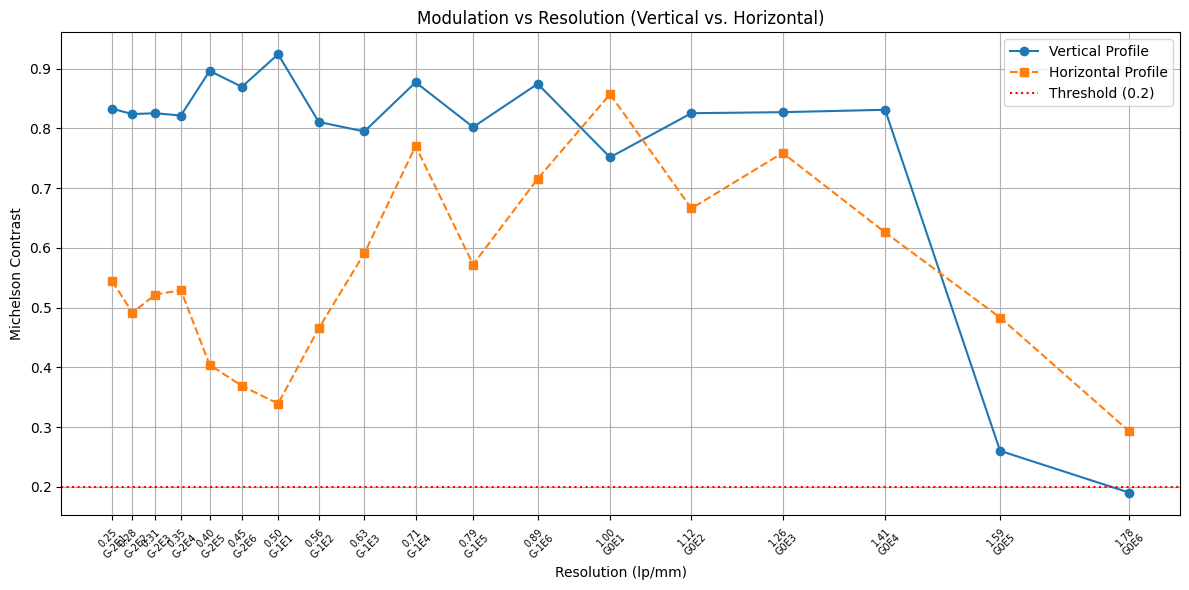


✅ ΔC < 0.5 조건을 만족하는 최대 해상도: 1.587 lp/mm
최대 분해 가능한 해상도: 1.587 lp/mm
최대 분해능 Group: 0, Element: 5
상세 결과:
[{'group': -2, 'element': 1, 'lpmm': 0.25, 'mod_v': 0.8327626025292688, 'mod_h': 0.5442668418344556, 'delta_c': 0.2884957606948132}, {'group': -2, 'element': 2, 'lpmm': 0.28061551207734325, 'mod_v': 0.8239059896486668, 'mod_h': 0.4913826717599921, 'delta_c': 0.3325233178886747}, {'group': -2, 'element': 3, 'lpmm': 0.3149802624737183, 'mod_v': 0.8253375466788266, 'mod_h': 0.5217236467217887, 'delta_c': 0.3036138999570379}, {'group': -2, 'element': 4, 'lpmm': 0.3535533905932738, 'mod_v': 0.821424663526781, 'mod_h': 0.5290354822570198, 'delta_c': 0.2923891812697612}, {'group': -2, 'element': 5, 'lpmm': 0.39685026299204984, 'mod_v': 0.8961538461502846, 'mod_h': 0.40427719514574, 'delta_c': 0.4918766510045446}, {'group': -1, 'element': 2, 'lpmm': 0.5612310241546865, 'mod_v': 0.8106085258673195, 'mod_h': 0.46529251288099926, 'delta_c': 0.3453160129863202}, {'group': -1, 'element': 3, 'lpmm'

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 수직 줄무늬
v_roi_list = [
    {"group": -2, "element": 1, "x": 140, "y": 205, "w": 48, "h": 48},
    {"group": -2, "element": 2, "x": 80, "y": 48, "w": 44, "h": 44},
    {"group": -2, "element": 3, "x": 74, "y": 100, "w": 40, "h": 40},
    {"group": -2, "element": 4, "x": 70, "y": 148, "w": 35, "h": 35},
    {"group": -2, "element": 5, "x": 65, "y": 188, "w": 31, "h": 31},
    {"group": -2, "element": 6, "x": 62, "y": 224, "w": 28, "h": 28},
    {"group": -1, "element": 1, "x": 190, "y": 49, "w": 26, "h": 26},
    {"group": -1, "element": 2, "x": 195, "y": 79, "w": 24, "h": 24},
    {"group": -1, "element": 3, "x": 200, "y": 105, "w": 21, "h": 21},
    {"group": -1, "element": 4, "x": 205, "y": 129, "w": 18, "h": 18},
    {"group": -1, "element": 5, "x": 209, "y": 149, "w": 16, "h": 16},
    {"group": -1, "element": 6, "x": 212, "y": 166, "w": 15, "h": 15},
    {"group":  0, "element": 1, "x": 161, "y": 170, "w": 14, "h": 14},
    {"group":  0, "element": 2, "x": 142, "y": 123, "w": 12, "h": 12},
    {"group":  0, "element": 3, "x": 141, "y": 138, "w": 11, "h": 11},
    {"group":  0, "element": 4, "x": 140, "y": 151, "w": 10, "h": 10},
    {"group":  0, "element": 5, "x": 139, "y": 164, "w": 9, "h": 9},
    {"group":  0, "element": 6, "x": 138, "y": 175, "w": 8, "h": 8},
]

# 수평 줄무늬
h_roi_list = [
    {"group": -2, "element": 1, "x": 197, "y": 205, "w": 48, "h": 48},
    {"group": -2, "element": 2, "x": 30, "y": 48, "w": 44, "h": 44},
    {"group": -2, "element": 3, "x": 29, "y": 101, "w": 40, "h": 40},
    {"group": -2, "element": 4, "x": 30, "y": 148, "w": 35, "h": 35},
    {"group": -2, "element": 5, "x": 30, "y": 188, "w": 31, "h": 31},
    {"group": -2, "element": 6, "x": 30, "y": 223, "w": 28, "h": 28},
    {"group": -1, "element": 1, "x": 218, "y": 49, "w": 26, "h": 26},
    {"group": -1, "element": 2, "x": 220, "y": 79, "w": 24, "h": 24},
    {"group": -1, "element": 3, "x": 223, "y": 105, "w": 21, "h": 21},
    {"group": -1, "element": 4, "x": 225, "y": 129, "w": 18, "h": 18},
    {"group": -1, "element": 5, "x": 227, "y": 149, "w": 16, "h": 16},
    {"group": -1, "element": 6, "x": 228, "y": 166, "w": 15, "h": 15},
    {"group":  0, "element": 1, "x": 175, "y": 170, "w": 14, "h": 14},
    {"group":  0, "element": 2, "x": 130, "y": 123, "w": 12, "h": 12},
    {"group":  0, "element": 3, "x": 130, "y": 138, "w": 11, "h": 11},
    {"group":  0, "element": 4, "x": 130, "y": 151, "w": 10, "h": 10},
    {"group":  0, "element": 5, "x": 130, "y": 164, "w": 9, "h": 9},
    {"group":  0, "element": 6, "x": 130, "y": 175, "w": 8, "h": 8},
]

def get_lpmm(group, element):
    return 2**group * (2 ** ((element - 1) / 6.0))

def compute_modulation(profile):
    max_val = np.max(profile)
    min_val = np.min(profile)
    return (max_val - min_val) / (max_val + min_val + 1e-9)


def analyze_joint_resolution(image_path, v_roi_list, h_roi_list, threshold=0.2, delta_c_max=0.5):
    if 'zssr' in image_path:
        multiplier = 2
    else:
        multiplier = 1

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.equalizeHist(img)

    best_lpmm = 0
    matched_results = []

    key_v = {(r['group'], r['element']): r for r in v_roi_list}
    key_h = {(r['group'], r['element']): r for r in h_roi_list}
    common_keys = sorted(set(key_v.keys()) & set(key_h.keys()))

    resolutions = []
    vertical_mods = []
    horizontal_mods = []

    for group, element in common_keys:
        rv = key_v[(group, element)]
        rh = key_h[(group, element)]

        x_v, y_v, w_v, h_v = [int(rv[k]*multiplier) for k in ['x', 'y', 'w', 'h']]
        x_h, y_h, w_h, h_h = [int(rh[k]*multiplier) for k in ['x', 'y', 'w', 'h']]

        pv = img[y_v:y_v+h_v, x_v:x_v+w_v]
        ph = img[y_h:y_h+h_h, x_h:x_h+w_h]
        if pv.size == 0 or ph.size == 0:
            continue

        mod_h = compute_modulation(np.mean(pv, axis=0))  # 수평 프로파일 (수직 줄무늬)
        mod_v = compute_modulation(np.mean(ph, axis=1))  # 수직 프로파일 (수평 줄무늬)
        delta_c = abs(mod_v - mod_h)
        lpmm = get_lpmm(group, element)

        resolutions.append(lpmm)
        vertical_mods.append(mod_v)
        horizontal_mods.append(mod_h)

        print(f"G{group}E{element} | lp/mm: {lpmm:.3f} | Mod(V): {mod_v:.3f}, Mod(H): {mod_h:.3f}, ΔC: {delta_c:.3f}")

        if mod_v >= threshold and mod_h >= threshold and delta_c < delta_c_max:
            matched_results.append({
                "group": group,
                "element": element,
                "lpmm": lpmm,
                "mod_v": mod_v,
                "mod_h": mod_h,
                "delta_c": delta_c
            })
            best_lpmm = max(best_lpmm, lpmm)

    # ✅ 시각화 추가
    plt.figure(figsize=(12, 6))
    plt.plot(resolutions, vertical_mods, 'o-', label='Vertical Profile')
    plt.plot(resolutions, horizontal_mods, 's--', label='Horizontal Profile')
    plt.axhline(threshold, color='r', linestyle=':', label=f'Threshold ({threshold})')
     # x축 라벨에 Group, Element 정보 추가
    x_labels = [f'{res:.2f}\nG{g}E{e}' for res, (g, e) in zip(resolutions, common_keys)]
    plt.xticks(resolutions, x_labels, rotation=45, fontsize=7)
    
    plt.xlabel('Resolution (lp/mm)')
    plt.ylabel('Michelson Contrast')
    plt.title('Modulation vs Resolution (Vertical vs. Horizontal)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n✅ ΔC < {delta_c_max} 조건을 만족하는 최대 해상도: {best_lpmm:.3f} lp/mm")
    return best_lpmm, matched_results

# 사용 예시
image_path = '../hyperspectral/thz_new/resol1951_2_e_2.0THz.png'
# image_path = '../hyperspectral/centernorm_step0.1_reshapev2.0x5_shift1/resol1951_2_e_2.0THz.png'
# image_path = '../results_main/d2d/2.0040/2.0040THz(2.0040to2.5050).png' # 3.1681
image_path = '../results_main/o2o_centernorm/2.0/resol1951_2_e_2.0THz(1.5to2.3).png' # 2.8850
# image_path = '../results_main/o2o_latest_ZSSR/2.0/resol1951_2_e_2.0THz(1.5to2.0).png' # 2.8850
# image_path = '../results_main/resol1951_2_e_2.0THz(1.5to2.0)_zssr.png' # 3.1620
# image_path = '../results_main/recurrent/resol1951_2_e_2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0)).png'

resolution, matched_results = analyze_joint_resolution(image_path, v_roi_list, h_roi_list)
print(f"최대 분해 가능한 해상도: {resolution:.3f} lp/mm")

# 최대 해상도의 group과 element 찾기
max_result = max(matched_results, key=lambda x: x['lpmm'])
print(f"최대 분해능 Group: {max_result['group']}, Element: {max_result['element']}")
print(f"상세 결과:")
print(matched_results)


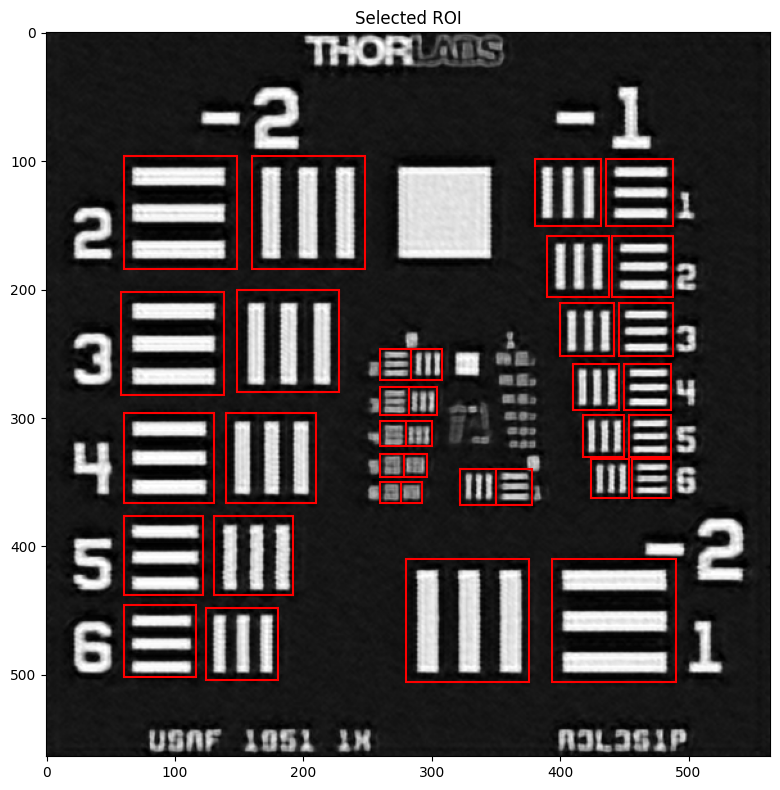

In [11]:
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.title("Selected ROI")
for roi in v_roi_list:
    rect = plt.Rectangle((roi["x"]*multiplier, roi["y"]*multiplier), roi["w"]*multiplier, roi["h"]*multiplier,
                         edgecolor='red', facecolor='none', linewidth=1.5)
    plt.gca().add_patch(rect)
for roi in h_roi_list:
    rect = plt.Rectangle((roi["x"]*multiplier, roi["y"]*multiplier), roi["w"]*multiplier, roi["h"]*multiplier,
                         edgecolor='red', facecolor='none', linewidth=1.5)
    plt.gca().add_patch(rect)
plt.tight_layout()
plt.show()

NameError: name 'v_roi_list' is not defined

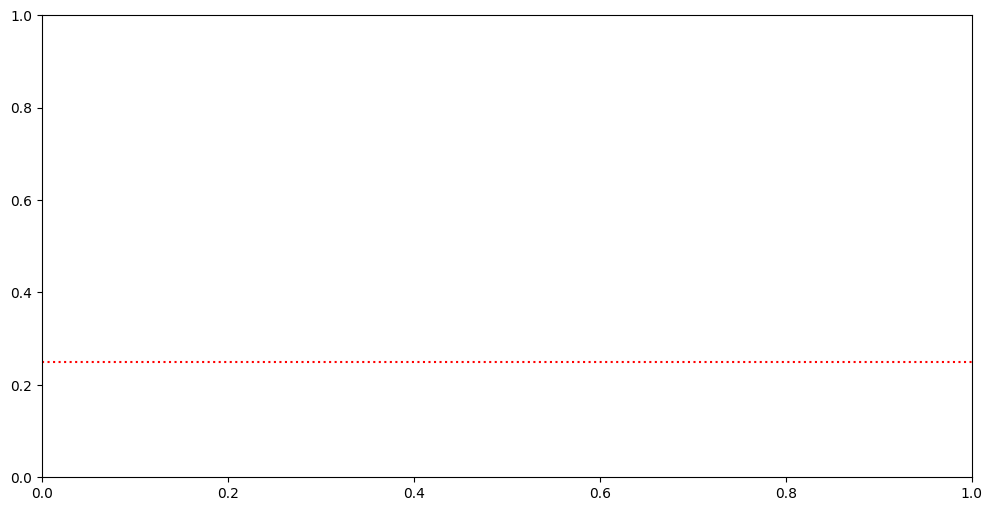

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_lpmm(group, element):
    return 2**group * (2 ** ((element - 1) / 6.0))

def compute_modulation(profile):
    max_val = np.max(profile)
    min_val = np.min(profile)
    return (max_val - min_val) / (max_val + min_val + 1e-9)


def analyze_joint_resolution(image_path, v_roi_list, h_roi_list, i, threshold=0.2, delta_c_max=0.5):
    if 'zssr' in image_path:
        multiplier = 2
    else:
        multiplier = 1

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.equalizeHist(img)

    best_lpmm = 0
    matched_results = []

    key_v = {(r['group'], r['element']): r for r in v_roi_list}
    key_h = {(r['group'], r['element']): r for r in h_roi_list}
    common_keys = sorted(set(key_v.keys()) & set(key_h.keys()))

    resolutions = []
    vertical_mods = []
    horizontal_mods = []

    for group, element in common_keys:
        rv = key_v[(group, element)]
        rh = key_h[(group, element)]

        x_v, y_v, w_v, h_v = [int(rv[k]*multiplier) for k in ['x', 'y', 'w', 'h']]
        x_h, y_h, w_h, h_h = [int(rh[k]*multiplier) for k in ['x', 'y', 'w', 'h']]

        pv = img[y_v:y_v+h_v, x_v:x_v+w_v]
        ph = img[y_h:y_h+h_h, x_h:x_h+w_h]
        if pv.size == 0 or ph.size == 0:
            continue

        mod_h = compute_modulation(np.mean(pv, axis=0))  # 수평 프로파일 (수직 줄무늬)
        mod_v = compute_modulation(np.mean(ph, axis=1))  # 수직 프로파일 (수평 줄무늬)
        delta_c = abs(mod_v - mod_h)
        lpmm = get_lpmm(group, element)

        resolutions.append(lpmm)
        vertical_mods.append(mod_v)
        horizontal_mods.append(mod_h)

        print(f"G{group}E{element} | lp/mm: {lpmm:.3f} | Mod(V): {mod_v:.3f}, Mod(H): {mod_h:.3f}, ΔC: {delta_c:.3f}")

        if mod_v >= threshold and mod_h >= threshold and delta_c < delta_c_max:
            matched_results.append({
                "group": group,
                "element": element,
                "lpmm": lpmm,
                "mod_v": mod_v,
                "mod_h": mod_h,
                "delta_c": delta_c
            })
            best_lpmm = max(best_lpmm, lpmm)

    # ✅ 시각화 추가
    if i == '1.0THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C0')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C0')
    elif i == '1.2THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C1')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C1')
    elif i == '1.4THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C2')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C2')
    elif i == '1.6THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C3')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C3')
    elif i == '1.8THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C4')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C4')
    elif i == '2.0THz':     
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C5')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C5')
    elif i == '2.2THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C6')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C6')
    elif i == '2.4THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C7')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C7')
    elif i == '2.6THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C8')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C8')
    elif i == '2.8THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C9')
        plt.plot(resolutions, horizontal_mods, 's--', label=f'{i} Horizontal Profile', color='C9')
    
     # x축 라벨에 Group, Element 정보 추가
    x_labels = [f'{res:.2f}\nG{g}E{e}' for res, (g, e) in zip(resolutions, common_keys)]
    plt.xticks(resolutions, x_labels, rotation=45, fontsize=7)
    
    plt.xlabel('Resolution (lp/mm)')
    plt.ylabel('Michelson Contrast')
    plt.title('Modulation vs Resolution (Vertical vs. Horizontal)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.show()

    print(f"\n✅ ΔC < {delta_c_max} 조건을 만족하는 최대 해상도: {best_lpmm:.3f} lp/mm")
    return best_lpmm, matched_results

# 사용 예시
plt.figure(figsize=(12, 6))
threshold = 0.25
plt.axhline(threshold, color='r', linestyle=':', label=f'Threshold ({threshold})')
for i in ['1.0THz', '1.2THz','1.4THz', '1.6THz', '1.8THz','2.0THz', '2.2THz', '2.4THz', '2.6THz']:
# for i in ['2.0THz', '2.2THz', '2.4THz', '2.6THz']:
    image_path = f'../hyperspectral/thz_new/resol1951_2_e_{i}.png'
    resolution, matched_results = analyze_joint_resolution(image_path, v_roi_list, h_roi_list, i)
    print(f"최대 분해 가능한 해상도: {resolution:.3f} lp/mm")
    

    # 최대 해상도의 group과 element 찾기
    max_result = max(matched_results, key=lambda x: x['lpmm'])
    print(f"최대 분해능 Group: {max_result['group']}, Element: {max_result['element']}")
plt.show()


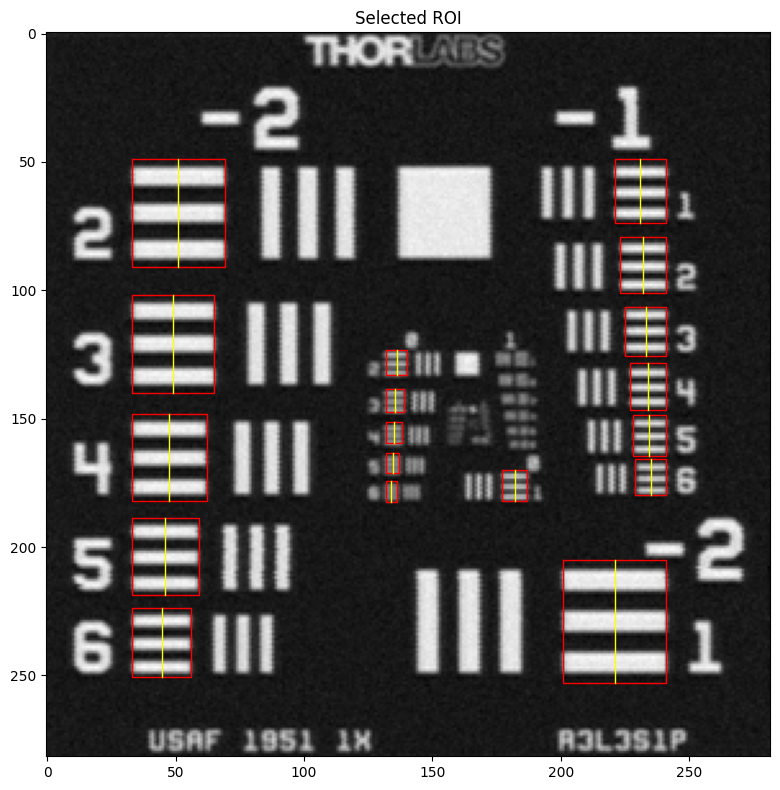

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 수평 줄무늬
h_roi_list = [
    {"group": -2, "element": 1, "x": 201, "y": 205, "w": 40, "h": 48},
    {"group": -2, "element": 2, "x": 33, "y": 49, "w": 36, "h": 42},
    {"group": -2, "element": 3, "x": 33, "y": 105 - (38/6/2), "w": 32, "h": 38},
    {"group": -2, "element": 4, "x": 33, "y": 151 - (34/6/2), "w": 29, "h": 34},
    {"group": -2, "element": 5, "x": 33, "y": 191 - (30/6/2), "w": 26, "h": 30},
    {"group": -2, "element": 6, "x": 33, "y": 226 - (27/6/2), "w": 23, "h": 27},
    {"group": -1, "element": 1, "x": 221, "y": 51 - (25/6/2), "w": 20, "h": 25},
    {"group": -1, "element": 2, "x": 223, "y": 81 - (22/6/2), "w": 18, "h": 22},
    {"group": -1, "element": 3, "x": 225, "y": 108 - (19/6/2), "w": 16, "h": 19},
    {"group": -1, "element": 4, "x": 227, "y": 130 - (18/6/2), "w": 14, "h": 18},
    {"group": -1, "element": 5, "x": 228, "y": 150 - (16/6/2), "w": 13, "h": 16},
    {"group": -1, "element": 6, "x": 229, "y": 167 - (14/6/2), "w": 12, "h": 14},
    {"group":  0, "element": 1, "x": 177, "y": 171 - (12/6/2), "w": 10, "h": 12},
    {"group":  0, "element": 2, "x": 132, "y": 124 - (10/6/2), "w": 8, "h": 10},
    {"group":  0, "element": 3, "x": 132, "y": 139 - (9/6/2), "w": 7, "h": 9},
    {"group":  0, "element": 4, "x": 132, "y": 152 - (8/6/2), "w": 6, "h": 8},
    {"group":  0, "element": 5, "x": 132, "y": 164 - (8/6/2), "w": 5, "h": 8},
    {"group":  0, "element": 6, "x": 132, "y": 175 - (8/6/2), "w": 4, "h": 8},
]

img_path = '../hyperspectral/thz_new/resol1951_2_e_2.2THz.png'
# img_path = '../results_main/o2o_centernorm/2.0/resol1951_2_e_2.0THz(1.5to2.3).png' # 2.8850

if 'zssr' in img_path:
    multiplier = 2
else:
    multiplier = 1
img = cv2.imread(img_path)
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.title("Selected ROI")

for roi in h_roi_list:
    rect = plt.Rectangle((roi["x"]*multiplier, roi["y"]*multiplier), roi["w"]*multiplier, roi["h"]*multiplier,
                         edgecolor='red', facecolor='none', linewidth=1)
    # 네모(ROI) 가운데에 수직선을 그립니다.
    center_x = roi["x"]*multiplier + (roi["w"]*multiplier)/2
    plt.plot([center_x, center_x], [roi["y"]*multiplier, roi["y"]*multiplier + roi["h"]*multiplier], color='yellow', linewidth=1)
    plt.gca().add_patch(rect)
plt.tight_layout()
plt.show()

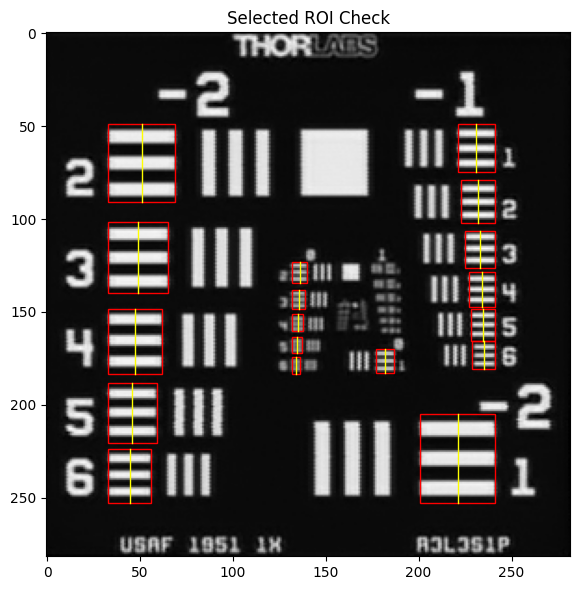

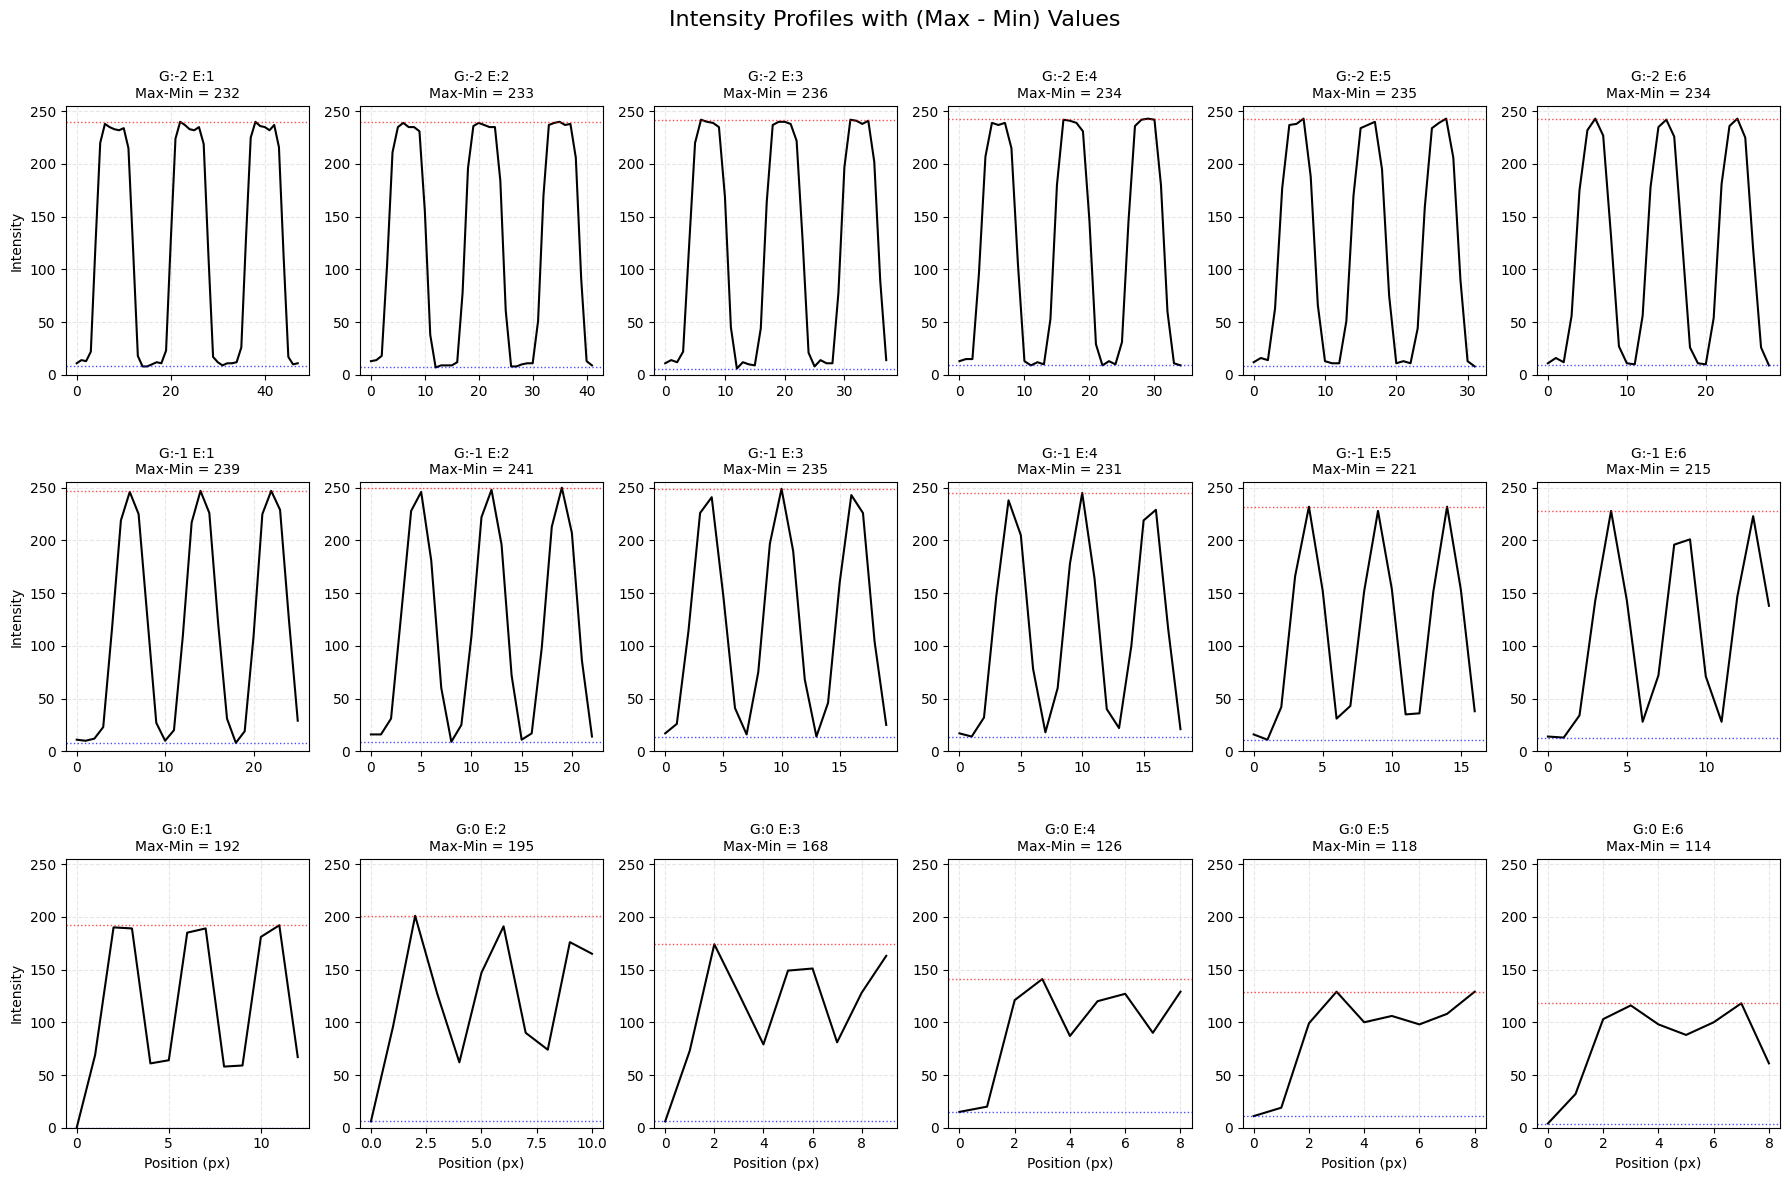

In [ ]:
### Min-Max 차이 해상도
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 수평 줄무늬 데이터
h_roi_list = [
    {"group": -2, "element": 1, "x": 201, "y": 205, "w": 40, "h": 48},
    {"group": -2, "element": 2, "x": 33, "y": 49, "w": 36, "h": 42},
    {"group": -2, "element": 3, "x": 33, "y": 105 - (38/6/2), "w": 32, "h": 38},
    {"group": -2, "element": 4, "x": 33, "y": 151 - (34/6/2), "w": 29, "h": 35},
    {"group": -2, "element": 5, "x": 33, "y": 191 - (30/6/2), "w": 26, "h": 32},
    {"group": -2, "element": 6, "x": 33, "y": 226 - (27/6/2), "w": 23, "h": 29},
    {"group": -1, "element": 1, "x": 221, "y": 51 - (25/6/2), "w": 20, "h": 26},
    {"group": -1, "element": 2, "x": 223, "y": 81 - (22/6/2), "w": 18, "h": 23},
    {"group": -1, "element": 3, "x": 225, "y": 108 - (19/6/2), "w": 16, "h": 20},
    {"group": -1, "element": 4, "x": 227, "y": 130 - (18/6/2), "w": 14, "h": 19},
    {"group": -1, "element": 5, "x": 228, "y": 150 - (16/6/2), "w": 13, "h": 17},
    {"group": -1, "element": 6, "x": 229, "y": 167 - (14/6/2), "w": 12, "h": 15},
    {"group":  0, "element": 1, "x": 177, "y": 171 - (12/6/2), "w": 10, "h": 13},
    {"group":  0, "element": 2, "x": 132, "y": 124 - (10/6/2), "w": 8, "h": 11},
    {"group":  0, "element": 3, "x": 132, "y": 139 - (9/6/2), "w": 7, "h": 10},
    {"group":  0, "element": 4, "x": 132, "y": 152 - (8/6/2), "w": 6, "h": 9},
    {"group":  0, "element": 5, "x": 132, "y": 164 - (8/6/2), "w": 5, "h": 9},
    {"group":  0, "element": 6, "x": 132, "y": 175 - (8/6/2), "w": 4, "h": 9},
]

# 이미지 경로 설정
img_path = '../hyperspectral/thz_new/resol1951_2_e_2.0THz.png'
img_path = '../hyperspectral/thz_new/resol1951_2_e_2.2THz.png'
img_path = '../results_main/d2d/2.0040/2.0040THz(2.0040to2.5050).png' # 3.1681
# img_path = '../results_main/o2o_latest_ZSSR/2.0/resol1951_2_e_2.0THz(1.5to2.0).png' # 2.8850
# img_path = '../results_main/resol1951_2_e_2.0THz(1.5to2.0)_zssr.png' # 3.1620
# img_path = '../results_main/recurrent/resol1951_2_e_2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0)).png'

if 'zssr' in img_path:
    multiplier = 2
else:
    multiplier = 1

img = cv2.imread(img_path)

if img is None:
    print(f"이미지를 찾을 수 없습니다: {img_path}")
else:
    if len(img.shape) == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray_img = img.copy()

    # ROI 시각화 (생략 없이 확인용으로 유지)
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title("Selected ROI Check")
    for roi in h_roi_list:
        rect = plt.Rectangle((roi["x"]*multiplier, roi["y"]*multiplier), roi["w"]*multiplier, roi["h"]*multiplier,
                             edgecolor='red', facecolor='none', linewidth=1)
        center_x = roi["x"]*multiplier + (roi["w"]*multiplier)/2
        plt.plot([center_x, center_x], [roi["y"]*multiplier, roi["y"]*multiplier + roi["h"]*multiplier], color='yellow', linewidth=1)
        plt.gca().add_patch(rect)
    plt.tight_layout()
    plt.show()

    # Axial Graph 그리기
    fig, axes = plt.subplots(3, 6, figsize=(18, 12)) # 세로 크기를 조금 늘렸습니다 (제목 공간 확보)
    fig.suptitle('Intensity Profiles with (Max - Min) Values', fontsize=16)
    axes = axes.flatten()

    for i, roi in enumerate(h_roi_list):
        x_center = int(roi["x"] * multiplier + (roi["w"] * multiplier) / 2)
        y_start = int(roi["y"] * multiplier)
        y_end = int(roi["y"] * multiplier + roi["h"] * multiplier)
        
        # 좌표 클리핑
        x_center = np.clip(x_center, 0, gray_img.shape[1]-1)
        y_start = np.clip(y_start, 0, gray_img.shape[0]-1)
        y_end = np.clip(y_end, 0, gray_img.shape[0])

        # 데이터 추출
        profile = gray_img[y_start:y_end, x_center]
        
        # --- Max, Min, 차이 계산 ---
        if len(profile) > 0:
            val_max = np.max(profile)
            val_min = np.min(profile)
            val_diff = val_max - val_min
        else:
            val_max = val_min = val_diff = 0

        ax = axes[i]
        ax.plot(profile, color='black', linewidth=1.5, label='Profile')
        
        # --- 시각화: Max(빨강), Min(파랑) 가이드라인 ---
        ax.axhline(val_max, color='red', linestyle=':', linewidth=1, alpha=0.7)
        ax.axhline(val_min, color='blue', linestyle=':', linewidth=1, alpha=0.7)
        
        # --- 제목에 차이(Diff) 표시 ---
        # G:Group, E:Element, D:Difference
        ax.set_title(f"G:{roi['group']} E:{roi['element']}\nMax-Min = {val_diff}", fontsize=10)
        
        # Y축 고정 (비교를 위해)
        ax.set_ylim(0, 255)
        
        # X축 라벨은 맨 아래 행만, Y축 라벨은 맨 왼쪽 열만 표시하여 깔끔하게 정리
        if i >= 12: # 마지막 행
            ax.set_xlabel('Position (px)')
        if i % 6 == 0: # 첫 번째 열
            ax.set_ylabel('Intensity')
            
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9, hspace=0.4) # 제목과 서브플롯 간 간격 조정
    plt.show()

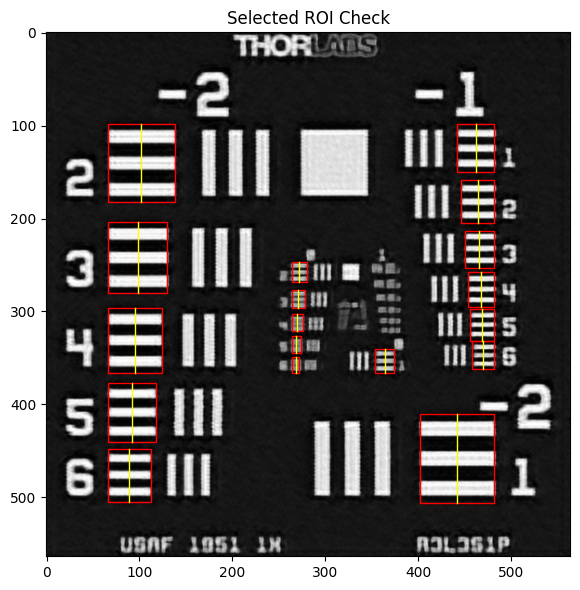

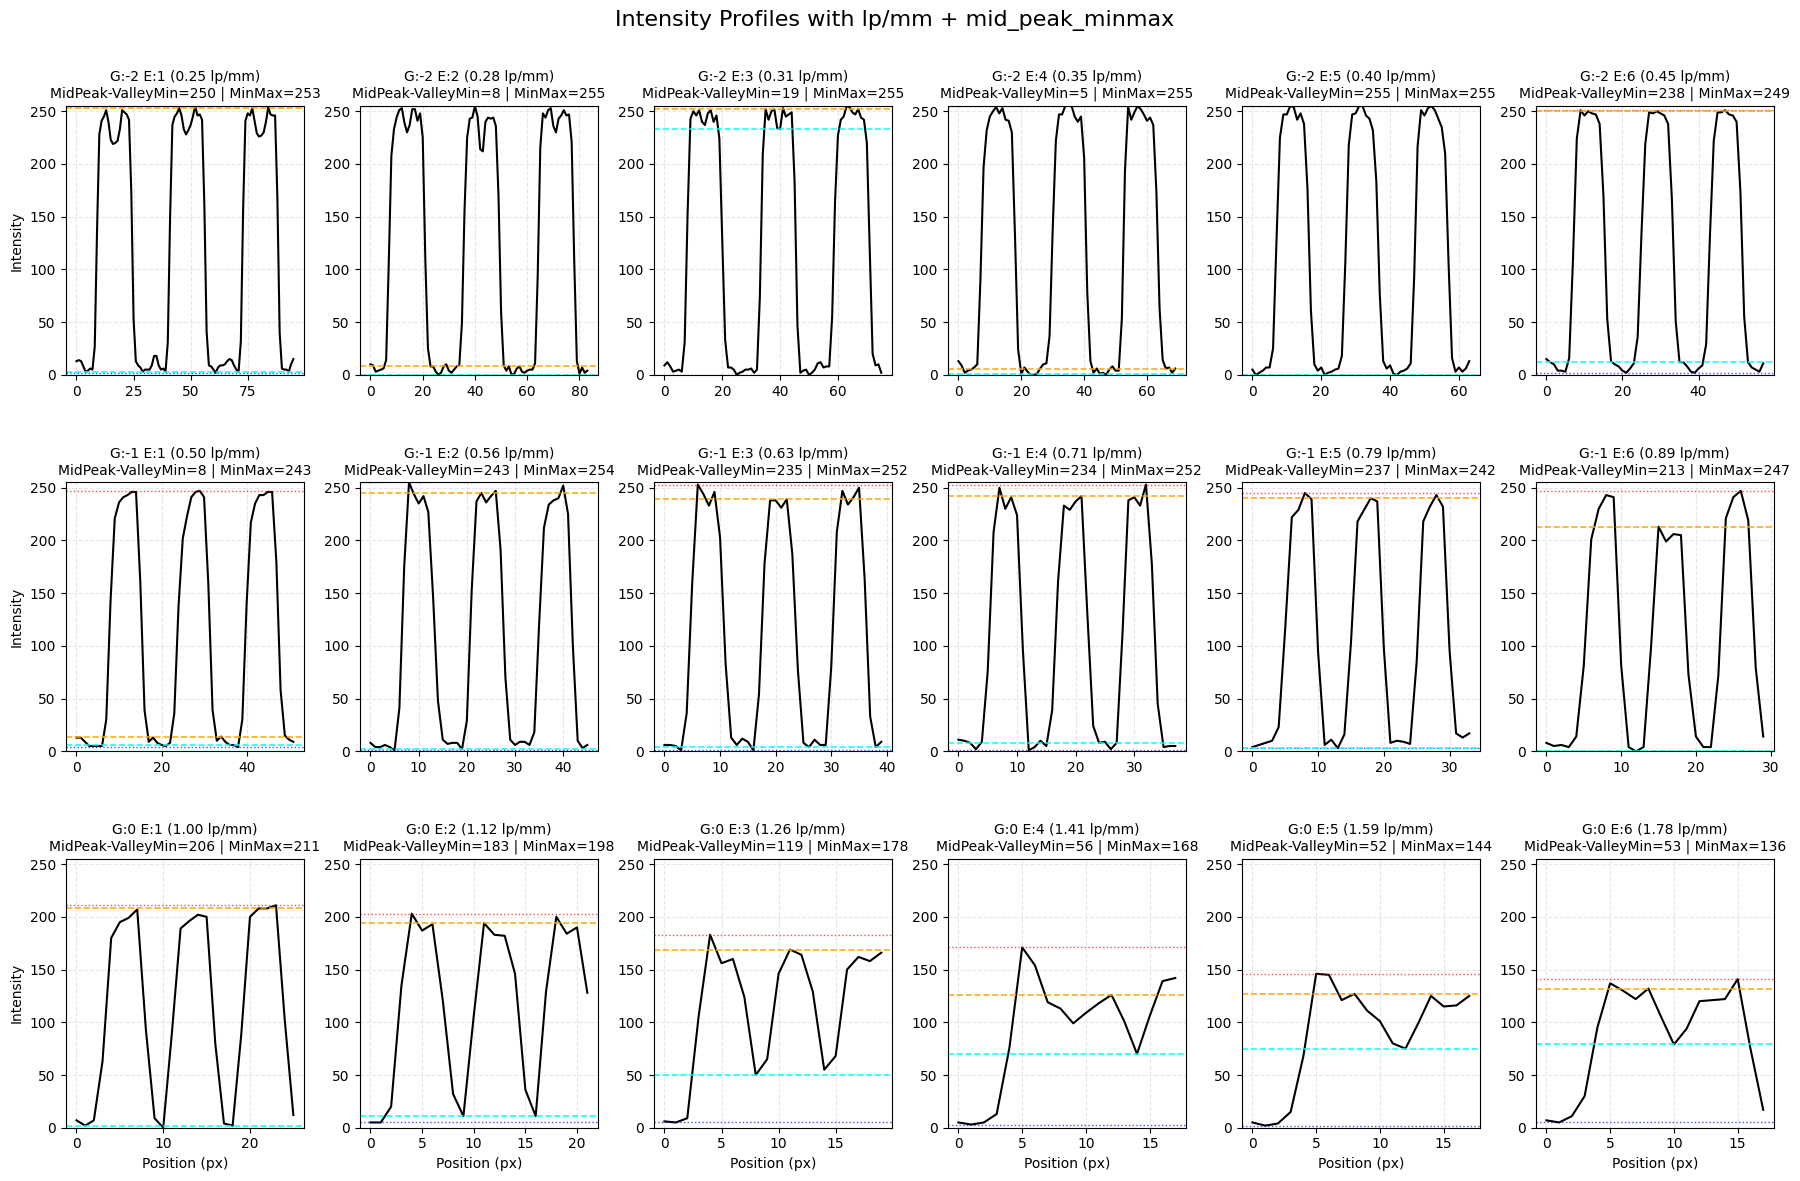

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 추가: lp/mm 계산
# =========================
def calc_lpmm(group, element):
    return 2 ** (group + (element - 1) / 6)

# =========================
# 설정: 여기만 바꾸면 됨
# =========================
metric_mode = "mid_peak_minmax"           # "minmax" | "top3_bottom2" | "mid_peak_minmax"
smooth_window = 1               # 1이면 스무딩 없음, 홀수 권장(3,5,7...)
min_peak_distance = 2           # 너무 가까운 peak 제거(간단한 거리 필터)

# 수평 줄무늬 데이터
h_roi_list = [
    {"group": -2, "element": 1, "x": 201, "y": 205, "w": 40, "h": 48},
    {"group": -2, "element": 2, "x": 33, "y": 49, "w": 36, "h": 42},
    {"group": -2, "element": 3, "x": 33, "y": 105 - (38/6/2), "w": 32, "h": 38},
    {"group": -2, "element": 4, "x": 33, "y": 151 - (34/6/2), "w": 29, "h": 35},
    {"group": -2, "element": 5, "x": 33, "y": 191 - (30/6/2), "w": 26, "h": 32},
    {"group": -2, "element": 6, "x": 33, "y": 226 - (27/6/2), "w": 23, "h": 29},
    {"group": -1, "element": 1, "x": 221, "y": 51 - (25/6/2), "w": 20, "h": 26},
    {"group": -1, "element": 2, "x": 223, "y": 81 - (22/6/2), "w": 18, "h": 23},
    {"group": -1, "element": 3, "x": 225, "y": 108 - (19/6/2), "w": 16, "h": 20},
    {"group": -1, "element": 4, "x": 227, "y": 130 - (18/6/2), "w": 14, "h": 19},
    {"group": -1, "element": 5, "x": 228, "y": 150 - (16/6/2), "w": 13, "h": 17},
    {"group": -1, "element": 6, "x": 229, "y": 167 - (14/6/2), "w": 12, "h": 15},
    {"group":  0, "element": 1, "x": 177, "y": 171 - (12/6/2), "w": 10, "h": 13},
    {"group":  0, "element": 2, "x": 132, "y": 124 - (10/6/2), "w": 8, "h": 11},
    {"group":  0, "element": 3, "x": 132, "y": 139 - (9/6/2), "w": 7, "h": 10},
    {"group":  0, "element": 4, "x": 132, "y": 152 - (8/6/2), "w": 6, "h": 9},
    {"group":  0, "element": 5, "x": 132, "y": 164 - (8/6/2), "w": 5, "h": 9},
    {"group":  0, "element": 6, "x": 132, "y": 175 - (8/6/2), "w": 4, "h": 9},
]

# 이미지 경로 설정
# img_path = '../hyperspectral/thz_new/resol1951_2_e_2.0THz.png'
# img_path = '../hyperspectral/thz_new/resol1951_2_e_2.2THz.png'
# img_path = '../results_main/d2d/2.0040/2.0040THz(2.0040to2.5050).png' # 3.1681
# img_path = '../results_main/o2o_latest_ZSSR/2.0/resol1951_2_e_2.0THz(1.5to2.0).png' # 2.8850
img_path = '../results_main/resol1951_2_e_2.0THz(1.5to2.0)_zssr.png' # 3.1620
# img_path = '../results_main/recurrent/resol1951_2_e_2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0)).png'

# =========================
# 유틸 함수들
# =========================
def moving_average(x: np.ndarray, w: int) -> np.ndarray:
    if w <= 1:
        return x.astype(np.float32)
    w = int(w)
    if w % 2 == 0:
        w += 1
    pad = w // 2
    xp = np.pad(x.astype(np.float32), (pad, pad), mode='edge')
    k = np.ones(w, dtype=np.float32) / w
    return np.convolve(xp, k, mode='valid')

def find_local_maxima(x: np.ndarray) -> np.ndarray:
    if len(x) < 3:
        return np.array([], dtype=int)
    return np.where((x[1:-1] > x[:-2]) & (x[1:-1] >= x[2:]))[0] + 1

def find_local_minima(x: np.ndarray) -> np.ndarray:
    if len(x) < 3:
        return np.array([], dtype=int)
    return np.where((x[1:-1] < x[:-2]) & (x[1:-1] <= x[2:]))[0] + 1

def suppress_close_peaks(idxs: np.ndarray, vals: np.ndarray, min_dist: int, mode: str) -> np.ndarray:
    if len(idxs) == 0:
        return idxs
    order = np.argsort(vals)
    if mode == "max":
        order = order[::-1]
    picked = []
    for oi in order:
        i = int(idxs[oi])
        if all(abs(i - p) >= min_dist for p in picked):
            picked.append(i)
    return np.array(sorted(picked), dtype=int)

# =========================
# 이미지 읽기
# =========================
multiplier = 2 if 'zssr' in img_path else 1
img = cv2.imread(img_path)

if img is None:
    print(f"이미지를 찾을 수 없습니다: {img_path}")
    raise SystemExit

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img.copy()

# ROI 시각화 (확인용)
# plt.figure(figsize=(6, 6))
# plt.imshow(img, cmap='gray')
# plt.title("Selected ROI Check")
# for roi in h_roi_list:
#     rect = plt.Rectangle((roi["x"]*multiplier, roi["y"]*multiplier),
#                          roi["w"]*multiplier, roi["h"]*multiplier,
#                          edgecolor='red', facecolor='none', linewidth=1)
#     center_x = roi["x"]*multiplier + (roi["w"]*multiplier)/2
#     plt.plot([center_x, center_x],
#              [roi["y"]*multiplier, roi["y"]*multiplier + roi["h"]*multiplier],
#              color='yellow', linewidth=1)
#     plt.gca().add_patch(rect)
# plt.tight_layout()
# plt.show()

# =========================
# Axial Graph
# =========================
fig, axes = plt.subplots(3, 6, figsize=(18, 12))
fig.suptitle(f'Intensity Profiles with lp/mm + {metric_mode}', fontsize=16)
axes = axes.flatten()

for i, roi in enumerate(h_roi_list):
    x_center = int(roi["x"] * multiplier + (roi["w"] * multiplier) / 2)
    y_start = int(roi["y"] * multiplier)
    y_end = int(roi["y"] * multiplier + roi["h"] * multiplier)

    x_center = np.clip(x_center, 0, gray_img.shape[1]-1)
    y_start = np.clip(y_start, 0, gray_img.shape[0]-1)
    y_end = np.clip(y_end, 0, gray_img.shape[0])

    profile = gray_img[y_start:y_end, x_center].astype(np.float32)

    ax = axes[i]
    ax.plot(profile, color='black', linewidth=1.5, label='Profile')

    # --- 기존 Min-Max(전체 구간) ---
    if len(profile) > 0:
        val_max = float(np.max(profile))
        val_min = float(np.min(profile))
        val_diff_minmax = val_max - val_min
    else:
        val_max = val_min = val_diff_minmax = 0.0

    ax.axhline(val_max, color='red', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(val_min, color='blue', linestyle=':', linewidth=1, alpha=0.7)

    # --- lp/mm 계산 ---
    lpmm = calc_lpmm(roi["group"], roi["element"])

    # --- 추가 옵션 계산 ---
    metric_note = f"MinMax={val_diff_minmax:.0f}"

    if len(profile) >= 3:
        sm = moving_average(profile, smooth_window)

        max_idxs = find_local_maxima(sm)
        min_idxs = find_local_minima(sm)

        if len(max_idxs) > 0:
            max_idxs = suppress_close_peaks(max_idxs, sm[max_idxs], min_peak_distance, mode="max")
        if len(min_idxs) > 0:
            min_idxs = suppress_close_peaks(min_idxs, sm[min_idxs], min_peak_distance, mode="min")

        # 옵션1: top3 mean - bottom2 mean
        if metric_mode == "top3_bottom2":
            if len(max_idxs) >= 3 and len(min_idxs) >= 2:
                top3 = np.sort(sm[max_idxs])[-3:]
                bot2 = np.sort(sm[min_idxs])[:2]
                top3_mean = float(np.mean(top3))
                bot2_mean = float(np.mean(bot2))
                opt1 = top3_mean - bot2_mean

                ax.axhline(top3_mean, color='green', linestyle='--', linewidth=1.2, alpha=0.9)
                ax.axhline(bot2_mean, color='purple', linestyle='--', linewidth=1.2, alpha=0.9)
                metric_note = f"MeanMax-MeanMin={opt1:.0f} | MinMax={val_diff_minmax:.0f}"
            else:
                metric_note = f"MeanMax-MeanMin=NA | MinMax={val_diff_minmax:.0f}"

        # 옵션2: middle peak min-max
        elif metric_mode == "mid_peak_minmax":
            if len(max_idxs) >= 1 and len(min_idxs) >= 1:
                max_sorted = np.sort(max_idxs)
                mid_peak_idx = int(max_sorted[len(max_sorted)//2])
                mid_peak_val = float(sm[mid_peak_idx])

                left_mins = min_idxs[min_idxs < mid_peak_idx]
                right_mins = min_idxs[min_idxs > mid_peak_idx]

                left_min_val = float(sm[int(left_mins[-1])]) if len(left_mins) > 0 else None
                right_min_val = float(sm[int(right_mins[0])]) if len(right_mins) > 0 else None

                candidates = [v for v in [left_min_val, right_min_val] if v is not None]
                if len(candidates) > 0:
                    chosen_min = float(np.min(candidates))
                    # 좌/우 valley 평균으로 바꾸고 싶으면:
                    # chosen_min = float(np.mean(candidates))

                    opt2 = mid_peak_val - chosen_min

                    ax.axhline(mid_peak_val, color='orange', linestyle='--', linewidth=1.2, alpha=0.9)
                    ax.axhline(chosen_min, color='cyan', linestyle='--', linewidth=1.2, alpha=0.9)
                    metric_note = f"MidPeak-ValleyMin={opt2:.0f} | MinMax={val_diff_minmax:.0f}"
                else:
                    metric_note = f"MidPeak-ValleyMin=NA | MinMax={val_diff_minmax:.0f}"
            else:
                metric_note = f"MidPeak-ValleyMin=NA | MinMax={val_diff_minmax:.0f}"

    # 제목
    ax.set_title(f"G:{roi['group']} E:{roi['element']} ({lpmm:.2f} lp/mm)\n{metric_note}", fontsize=10)

    ax.set_ylim(0, 255)
    if i >= 12:
        ax.set_xlabel('Position (px)')
    if i % 6 == 0:
        ax.set_ylabel('Intensity')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.9, hspace=0.4)
plt.show()


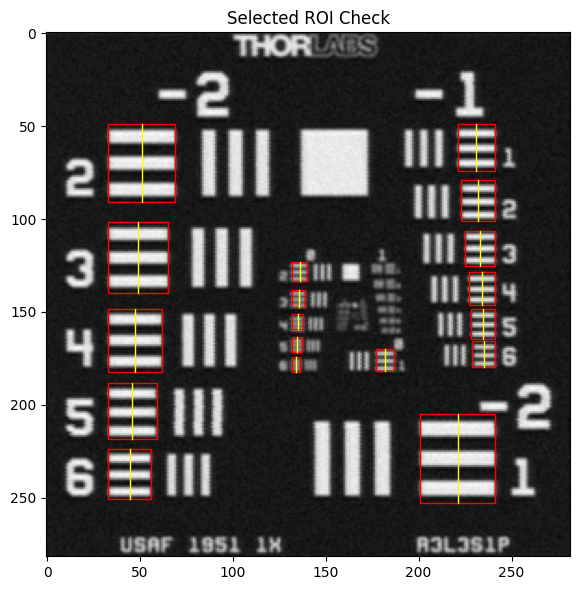

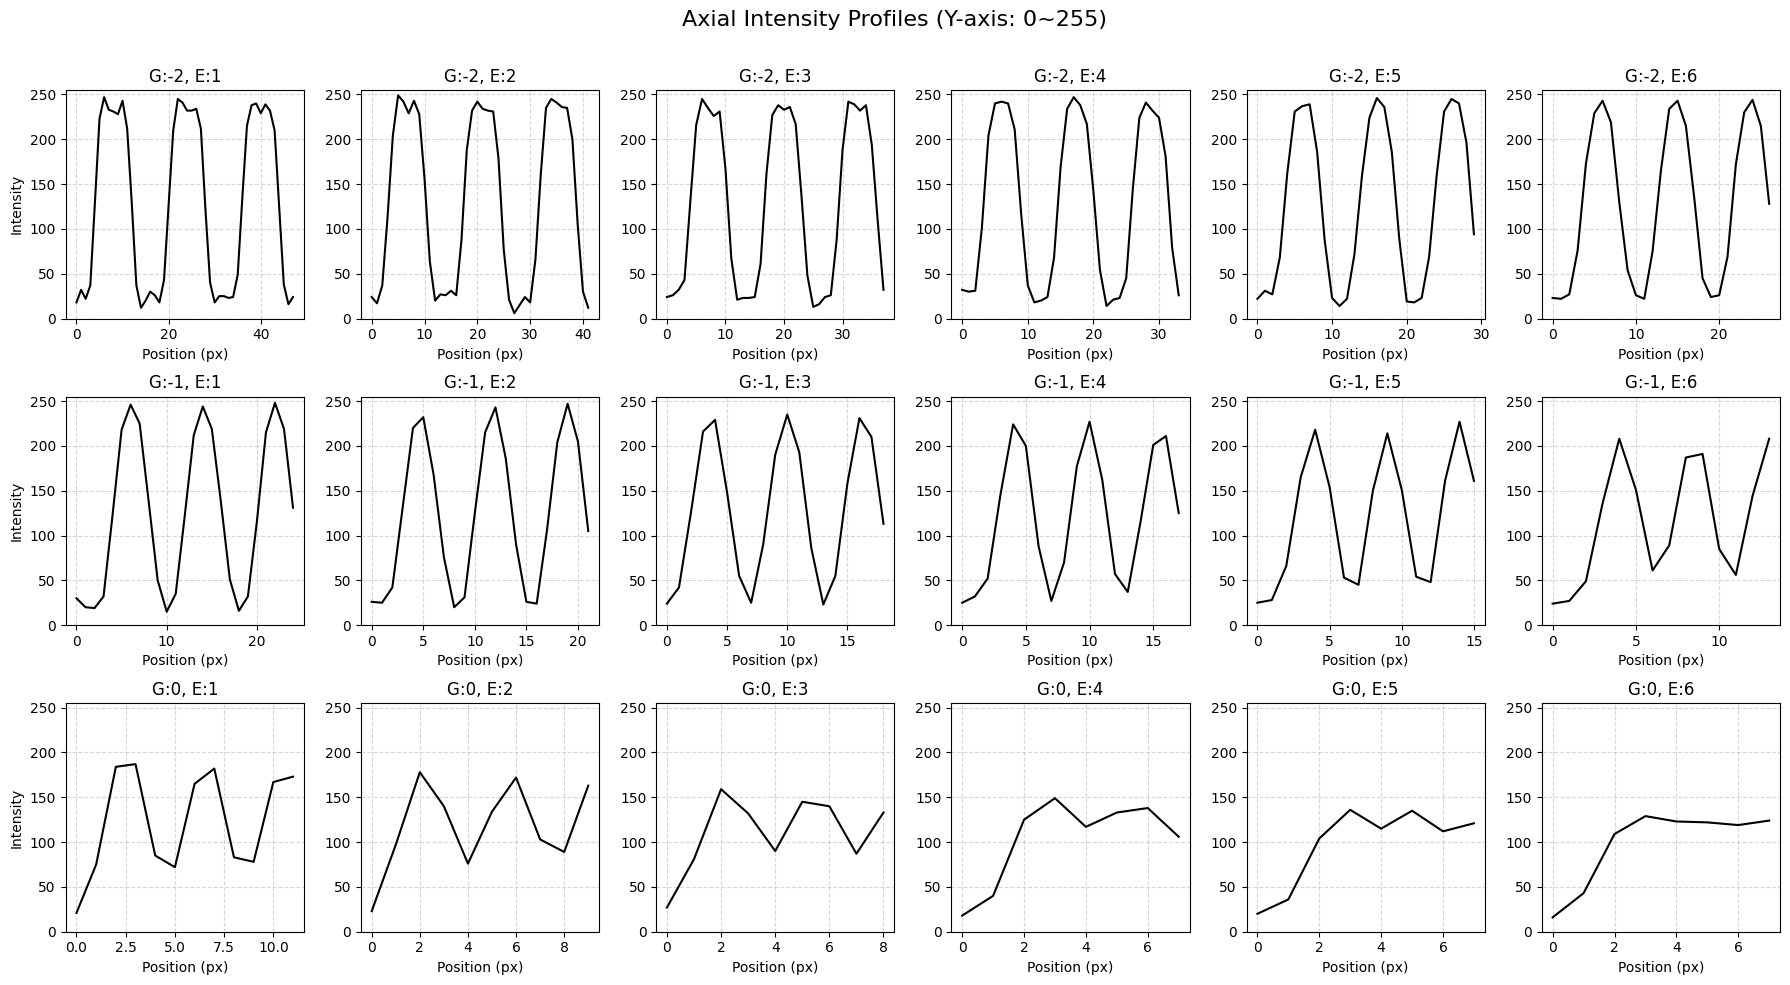

In [ ]:
def get_lpmm(group, element):
    return 2**group * (2 ** ((element - 1) / 6.0))
    
def compute_modulation(profile):
    max_val = np.max(profile)
    min_val = np.min(profile)
    mod = (max_val - min_val) / (max_val + min_val + 1e-9)
    # max_val, min_val이 너무 큰 경우, 0으로 처리
    if mod > 1:
        return 1.0
    return mod

def analyze_joint_resolution(image_path, h_roi_list, i, threshold=0.2, delta_c_max=0.5):
    if 'zssr' in image_path:
        multiplier = 2
    else:
        multiplier = 1

    img = cv2.imread(image_path)

    best_lpmm = 0
    matched_results = []

    key_h = {(r['group'], r['element']): r for r in h_roi_list}

    resolutions = []
    vertical_mods = []

    stop = False
    for group, element in key_h.keys():
        rh = key_h[(group, element)]

        x_h, y_h, w_h, h_h = [int(rh[k]*multiplier) for k in ['x', 'y', 'w', 'h']]

        ph = img[y_h:y_h+h_h, x_h:x_h+w_h]
        
        mod_v = compute_modulation(np.mean(ph, axis=1))  # 수직 프로파일 (수평 줄무늬)

        # center_x = x_h + w_h // 2
        # vertical_line = img[y_h:y_h+h_h, center_x:center_x+1]
        # mod_v = compute_modulation(vertical_line)
        # print(mod_v)
        lpmm = get_lpmm(group, element)

        resolutions.append(lpmm)
        vertical_mods.append(mod_v)

        # print(f"G{group}E{element} | lp/mm: {lpmm:.3f} | Mod(V): {mod_v:.3f}, Mod(H): {mod_h:.3f}, ΔC: {delta_c:.3f}")
        
        if mod_v > threshold:
            if stop == False:
                matched_results.append({
                    "group": group,
                    "element": element,
                    "lpmm": lpmm,
                    "mod_v": mod_v,
                })
                best_lpmm = max(best_lpmm, lpmm)
        else:
            stop = True

    # ✅ 시각화 추가
    if i == '1.0THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C0')
    elif i == '1.2THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C1')
    elif i == '1.4THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C2')
    elif i == '1.6THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C3')
    elif i == '1.8THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C4')
    elif i == '2.0THz':     
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C5')
    elif i == '2.2THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C6')
    elif i == '2.4THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C7')
    elif i == '2.6THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C8')
    elif i == '2.8THz':
        plt.plot(resolutions, vertical_mods, 'o-', label=f'{i} Vertical Profile', color='C9')
    
     # x축 라벨에 Group, Element 정보 추가
    x_labels = [f'{res:.2f}\nG{g}E{e}' for res, (g, e) in zip(resolutions, key_h.keys())]
    plt.xticks(resolutions, x_labels, rotation=45, fontsize=7)
    
    plt.xlabel('Resolution (lp/mm)')
    plt.ylabel('Michelson Contrast')
    plt.title('Modulation vs Resolution (Vertical)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.show()

    # print(f"\n최대 해상도: {best_lpmm:.3f} lp/mm")
    return best_lpmm, matched_results

# 사용 예시
plt.figure(figsize=(12, 6))
threshold = 0.7
plt.axhline(threshold, color='r', linestyle=':', label=f'Threshold ({threshold})')
for i in ['1.0THz', '1.2THz','1.4THz', '1.6THz', '1.8THz','2.0THz', '2.2THz', '2.4THz', '2.6THz']:
# for i in ['2.0THz', '2.2THz', '2.4THz', '2.6THz']:
    image_path = f'../hyperspectral/centernorm_step0.1_reshapev2.0x5_shift1/resol1951_2_e_{i}.png'
    resolution, matched_results = analyze_joint_resolution(image_path, h_roi_list, i, threshold=threshold)
    print(f"{i} THz 최대 분해 가능한 해상도: {resolution:.3f} lp/mm")
    
    
    # 최대 해상도의 group과 element 찾기
    max_result = max(matched_results, key=lambda x: x['lpmm'])
    print(f"최대 분해능 Group: {max_result['group']}, Element: {max_result['element']}")
    # print(matched_results)
plt.show()


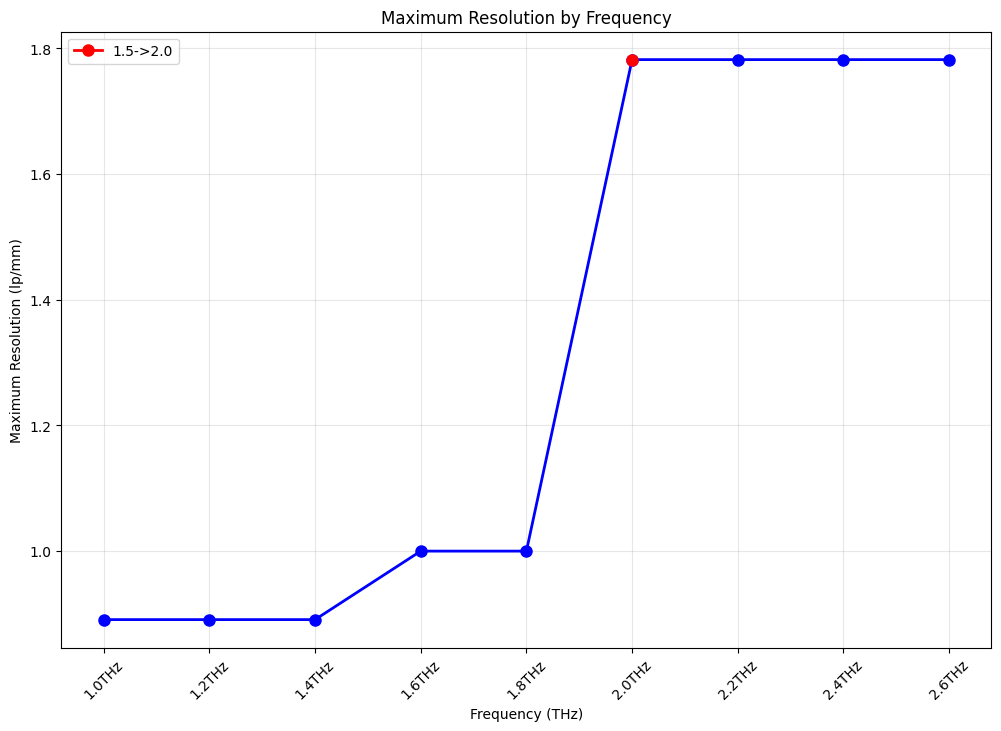

In [15]:
# 데이터 수집
frequencies = ['1.0THz', '1.2THz', '1.4THz', '1.6THz', '1.8THz', '2.0THz', '2.2THz', '2.4THz', '2.6THz']
resolutions = [0.891, 0.891, 0.891, 1.000, 1.000, 1.782, 1.782, 1.782, 1.782]
groups = [-1, -1, -1, 0, 0, 0, 0, 0, 0]
elements = [6, 6, 6, 1, 1, 6, 6, 6, 6]

# 그래프 생성
plt.figure(figsize=(12, 8))

plt.plot(frequencies, resolutions, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Frequency (THz)')
plt.ylabel('Maximum Resolution (lp/mm)')
plt.title('Maximum Resolution by Frequency')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 1.5->2.0 데이터도 2.0THz 위치에 플롯
frequencies_o2o = ['2.0THz']
o2o_resolutions = [1.782]
plt.plot(frequencies_o2o, o2o_resolutions, 'ro-', linewidth=2, markersize=8, label='1.5->2.0')
plt.legend()

G-2E1 | lp/mm: 0.250 | Mod(V): 0.905
G-2E2 | lp/mm: 0.281 | Mod(V): 0.973
G-2E3 | lp/mm: 0.315 | Mod(V): 0.980
G-2E4 | lp/mm: 0.354 | Mod(V): 0.961
G-2E5 | lp/mm: 0.397 | Mod(V): 0.961
G-2E6 | lp/mm: 0.445 | Mod(V): 0.979
G-1E1 | lp/mm: 0.500 | Mod(V): 0.999
G-1E2 | lp/mm: 0.561 | Mod(V): 0.995
G-1E3 | lp/mm: 0.630 | Mod(V): 0.993
G-1E4 | lp/mm: 0.707 | Mod(V): 0.995
G-1E5 | lp/mm: 0.794 | Mod(V): 0.901
G-1E6 | lp/mm: 0.891 | Mod(V): 0.952
G0E1 | lp/mm: 1.000 | Mod(V): 0.925
G0E2 | lp/mm: 1.122 | Mod(V): 0.910
G0E3 | lp/mm: 1.260 | Mod(V): 0.969
G0E4 | lp/mm: 1.414 | Mod(V): 0.866
G0E5 | lp/mm: 1.587 | Mod(V): 0.876
G0E6 | lp/mm: 1.782 | Mod(V): 0.917


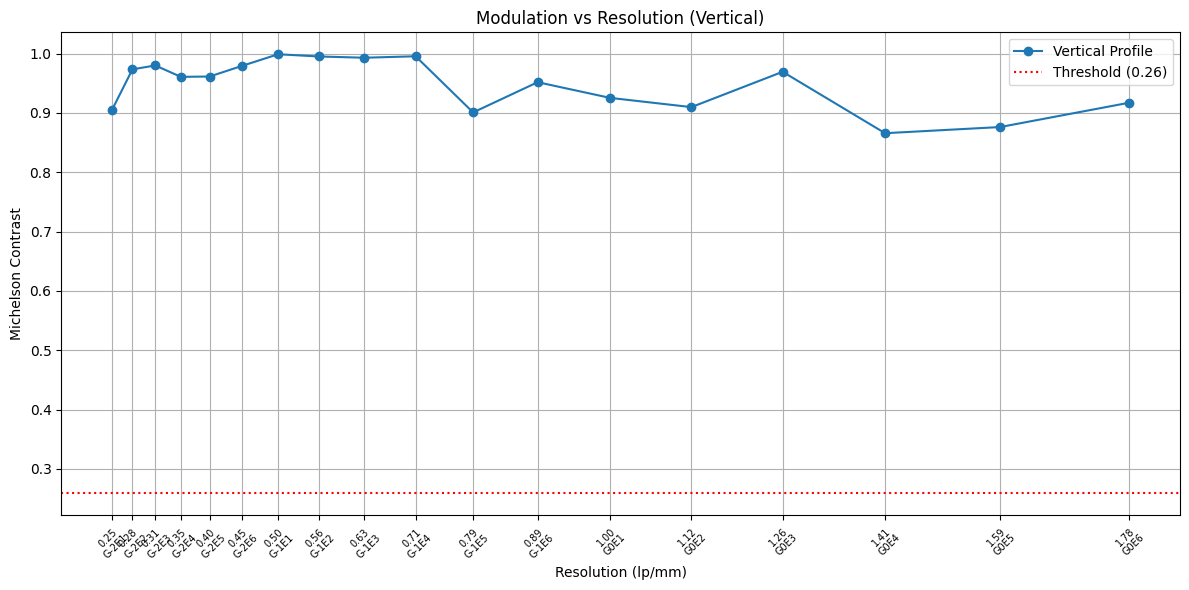


✅최대 해상도: 1.782 lp/mm
최대 분해 가능한 해상도: 1.782 lp/mm
최대 분해능 Group: 0, Element: 6
상세 결과:
[{'group': -2, 'element': 1, 'lpmm': 0.25, 'mod_v': 0.9053767585241651}, {'group': -2, 'element': 2, 'lpmm': 0.28061551207734325, 'mod_v': 0.9733599733560838}, {'group': -2, 'element': 3, 'lpmm': 0.3149802624737183, 'mod_v': 0.9799272362274046}, {'group': -2, 'element': 4, 'lpmm': 0.3535533905932738, 'mod_v': 0.9606913855550795}, {'group': -2, 'element': 5, 'lpmm': 0.39685026299204984, 'mod_v': 0.9612703330712636}, {'group': -2, 'element': 6, 'lpmm': 0.44544935907016964, 'mod_v': 0.9791376912339153}, {'group': -1, 'element': 1, 'lpmm': 0.5, 'mod_v': 0.9987995198039263}, {'group': -1, 'element': 2, 'lpmm': 0.5612310241546865, 'mod_v': 0.9950584007147549}, {'group': -1, 'element': 3, 'lpmm': 0.6299605249474366, 'mod_v': 0.9929185634760024}, {'group': -1, 'element': 4, 'lpmm': 0.7071067811865476, 'mod_v': 0.9953983318913041}, {'group': -1, 'element': 5, 'lpmm': 0.7937005259840997, 'mod_v': 0.90073081607438

In [16]:
def get_lpmm(group, element):
    return 2**group * (2 ** ((element - 1) / 6.0))

def compute_modulation(profile):
    max_val = np.max(profile)
    min_val = np.min(profile)
    return (max_val - min_val) / (max_val + min_val + 1e-9)


def analyze_joint_resolution(image_path, h_roi_list, threshold=0.26):
    if 'zssr' in image_path:
        multiplier = 2
    else:
        multiplier = 1

    img = cv2.imread(image_path)

    best_lpmm = 0
    matched_results = []

    key_h = {(r['group'], r['element']): r for r in h_roi_list}

    resolutions = []
    vertical_mods = []

    for group, element in key_h.keys():
        rh = key_h[(group, element)]

        x_h, y_h, w_h, h_h = [int(rh[k]*multiplier) for k in ['x', 'y', 'w', 'h']]

        ph = img[y_h:y_h+h_h, x_h:x_h+w_h]
        if ph.size == 0:
            continue

        mod_v = compute_modulation(np.mean(ph, axis=1))  # 수직 프로파일 (수평 줄무늬)
        lpmm = get_lpmm(group, element)

        resolutions.append(lpmm)
        vertical_mods.append(mod_v)

        print(f"G{group}E{element} | lp/mm: {lpmm:.3f} | Mod(V): {mod_v:.3f}")

        if mod_v >= threshold:
            matched_results.append({
                "group": group,
                "element": element,
                "lpmm": lpmm,
                "mod_v": mod_v,
            })
            best_lpmm = max(best_lpmm, lpmm)

    # ✅ 시각화 추가
    plt.figure(figsize=(12, 6))
    plt.plot(resolutions, vertical_mods, 'o-', label='Vertical Profile')
    plt.axhline(threshold, color='r', linestyle=':', label=f'Threshold ({threshold})')
     # x축 라벨에 Group, Element 정보 추가
    x_labels = [f'{res:.2f}\nG{g}E{e}' for res, (g, e) in zip(resolutions, key_h.keys())]
    plt.xticks(resolutions, x_labels, rotation=45, fontsize=7)
    
    plt.xlabel('Resolution (lp/mm)')
    plt.ylabel('Michelson Contrast')
    plt.title('Modulation vs Resolution (Vertical)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n✅최대 해상도: {best_lpmm:.3f} lp/mm")
    return best_lpmm, matched_results

# 사용 예시
# image_path = '../hyperspectral/thz_new/resol1951_2_e_0.5THz.png'
# image_path = '../hyperspectral/centernorm_step0.1_reshapev2.0x5_shift1/resol1951_2_e_2.0THz.png'
# image_path = '../results_main/d2d/2.0040/2.0040THz(2.0040to2.5050).png' # 3.1681
image_path = '../results_main/o2o_centernorm/2.0/resol1951_2_e_2.0THz(1.5to2.0).png' # 2.8850
# image_path = '../results_main/o2o_latest_ZSSR/2.0/resol1951_2_e_2.0THz(1.5to2.0).png' # 2.8850
# image_path = '../results_main/resol1951_2_e_2.0THz(1.5to2.0)_zssr.png' # 3.1620
# image_path = '../results_main/recurrent/resol1951_2_e_2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0)).png'

resolution, matched_results = analyze_joint_resolution(image_path, h_roi_list)
print(f"최대 분해 가능한 해상도: {resolution:.3f} lp/mm")

# 최대 해상도의 group과 element 찾기
max_result = max(matched_results, key=lambda x: x['lpmm'])
print(f"최대 분해능 Group: {max_result['group']}, Element: {max_result['element']}")
print(f"상세 결과:")
print(matched_results)